# Exercise:
1. Write a code to simulate 2D-ISING model with N grid points per each dimension. 
2. Compute total energy of the system.
3. Compute magnetization of the system.
4. Plot the magnetization as the function of temperature.

# Step:
1. Create initial configuration with $N^2$ sites
+ cold s= -1
+ random s= +1 or -1
+ hot s = 1
2. Compute changing energy $\Delta E = E_{final} - E_{initial}$ at lattice point $i,j$
3. Generate new configuration using Monte Carlo Metropolis method
+ if $\Delta E <= 0$, accept new spin or flip spin
+ if $\Delta E > 0$, flip spin based on Boltzmann distribution:

	- $p <= e^{-\beta \Delta E}$: accept new spin

	- $p > e^{-\beta \Delta E}$: reject new spin
4. Compute 2 quatities:

	a. total energy of the system
		$$E = -\sum_{i,j} s_i s_j$$ 
	where $i,j$ are neighbourhoods.
	
	b. Compute magnetization for each configuration after burn-in period

	$$ \langle |M| \rangle = \dfrac{1}{n}\sum_{i =1}^{n} |M_i|$$
	 with $n$ is the number of configurations and
	$$M_i = \dfrac{1}{N^2}\sum_{j=1}^{N^2} s_j$$
	c. Plot the magnetization and energy  as the function of $\beta$. 

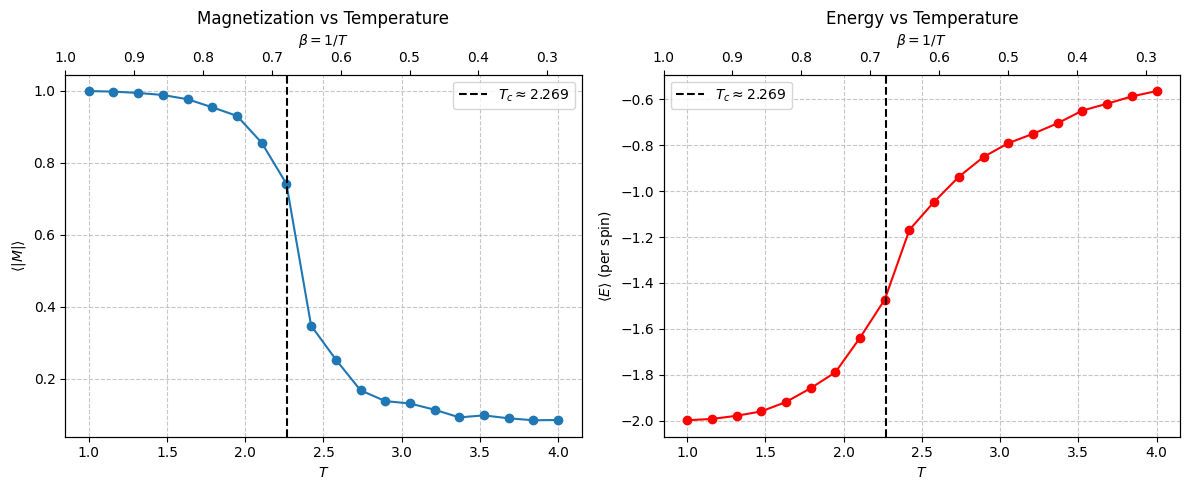

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def initial_config(N, mode="random"):
    """Generates the initial NxN spin lattice configuration."""
    if mode == "cold":
        return -np.ones((N, N), dtype=int)  # All spins down
    if mode == "hot":
        return np.ones((N, N), dtype=int)   # All spins up
    if mode == "random":
        return np.random.choice([1, -1], size=(N, N)) # Random spins
    raise ValueError("Unknown mode: choose 'cold', 'hot', or 'random'")


def delta_energy(s, i, j):
    """Computes the energy change for flipping spin s[i,j]."""
    N = s.shape[0]
    left = s[i, (j - 1) % N]
    right = s[i, (j + 1) % N]
    up = s[(i - 1) % N, j]
    down = s[(i + 1) % N, j]
    
    return 2 * s[i, j] * (left + right + up + down)

def total_energy(s):
    """Computes the total energy of the entire lattice."""
    N = s.shape[0]
    E = 0
    for i in range(N):
        for j in range(N):
            S = s[i, j]
            nb = s[(i + 1) % N, j] + s[i, (j + 1) % N]
            E += -S * nb
    return E

def magnetization(s):
    """Computes the average magnetization per spin."""
    N = s.shape[0]
    return np.sum(s) / (N**2)

def metropolis_sweep(s, beta):
    """
    Performs one full Monte Carlo sweep over the lattice.
    Visits N^2 sites in a random order to maintain detailed balance.
    """
    N = s.shape[0]
    # Randomize the order 
    idx = np.random.permutation(N * N)

    for flat_idx in idx:
        i, j = divmod(flat_idx, N) # Convert flat index back to 2D coordinates
        dE = delta_energy(s, i, j)

        # Metropolis criterion
        if dE <= 0 or np.random.rand() < np.exp(-beta * dE):
            s[i, j] *= -1

    return s

def simulate_ising(N, temperatures, n_equil=200, n_steps=200, mode="random"):
    """
    Runs the full Ising model simulation for a range of beta values.
    """
    mags = []
    energies = []

    for T in temperatures:
        beta = 1.0 / T
        s = initial_config(N, mode)

        # Burn-in / Equilibration 
        for _ in range(n_equil):
            s = metropolis_sweep(s, beta)

        # Measurement phase
        mag_samples = []
        eng_samples = []
        for _ in range(n_steps):
            s = metropolis_sweep(s, beta)
            mag_samples.append(abs(magnetization(s)))
            eng_samples.append(total_energy(s) / (N**2)) # Energy per spin

        # Average the samples for this specific beta
        mags.append(np.mean(mag_samples))
        energies.append(np.mean(eng_samples))

    return np.array(mags), np.array(energies)


# Parameters
N = 20
temperatures = np.linspace(1.0, 4.0, 20)

mags, energies = simulate_ising(N, temperatures, n_equil=500, n_steps=500, mode="random")

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Magnetization
ax1 = axes[0]
ax1.plot(temperatures, mags, marker="o")
ax1.axvline(x=2.269, color="k", linestyle="--", label=r"$T_c \approx 2.269$")
ax1.set_xlabel(r"$T$")
ax1.set_ylabel(r"$\langle |M| \rangle$")
ax1.set_title("Magnetization vs Temperature")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.7)

ax1b = ax1.twiny()
ax1b.set_xlim(1/temperatures[0], 1/temperatures[-1])
ax1b.set_xlabel(r"$\beta = 1/T$")

# Energy
ax2 = axes[1]
ax2.plot(temperatures, energies, marker="o", color="r")
ax2.axvline(x=2.269, color="k", linestyle="--", label=r"$T_c \approx 2.269$")
ax2.set_xlabel(r"$T$")
ax2.set_ylabel(r"$\langle E \rangle$ (per spin)")
ax2.set_title("Energy vs Temperature")
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.7)

ax2b = ax2.twiny()
ax2b.set_xlim(1/temperatures[0], 1/temperatures[-1])
ax2b.set_xlabel(r"$\beta = 1/T$")

plt.tight_layout()
plt.show()

> The exercise lists two separate plotting requirements —
> point 4 in *Exercise* asks for magnetization as a function of **temperature** $T$,
> while point 4c in *Step* asks for plots as a function of **$\beta$**.
> These are not two different plots: since $\beta = 1/T$, both axes carry identical physical
> information and differ only in scale. To satisfy both requirements simultaneously,
> the plots above display $T$ on the bottom axis and the corresponding $\beta = 1/T$
> on the top axis.

# Final Conclusion

The plots of Magnetization and Energy versus temperature $T$ clearly demonstrate the ferromagnetic phase transition of the 2D Ising model (with $k_B = 1$, so $\beta = 1/T$):

- **High Temperature regime ($T > T_c$):** Thermal fluctuations dominate the system. The spins are randomly oriented, causing the average magnetization $\langle |M| \rangle$ to hover near 0. Correspondingly, the energy per spin is relatively high (closer to zero), representing a disordered, paramagnetic state.

- **Phase Transition ($T_c \approx 2.269$):** As temperature decreases, the system approaches the critical point. The magnetization begins to rise sharply and the energy drops steeply as neighboring spins start to align. The exact analytical value is

$$
T_c = \frac{2}{\ln(1+\sqrt{2})} \approx 2.269
$$

- **Low Temperature regime ($T < T_c$):** The interaction energy overcomes thermal noise. The system undergoes spontaneous symmetry breaking, settling into a highly ordered ferromagnetic state. This is evidenced by the magnetization $\langle |M| \rangle$ asymptotically approaching 1, and the energy plateauing at its minimum possible value.

Overall, the Monte Carlo simulation successfully captures the expected thermodynamic behavior and phase transition inherent to the 2D Ising model.